In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import json
from datetime import datetime

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.is_available()}")
print(f"GPU 이름: {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu118
GPU: True
GPU 이름: NVIDIA GeForce RTX 2060 SUPER


In [3]:
CONFIG = {
    # 경로
    "data_dir": "../data/openfake",
    "save_dir": "../models/openfake",
    "checkpoint_path": "../models/openfake/checkpoint.pth",
    "best_model_path": "../models/openfake/best_model.pth",
    "history_path": "../models/openfake/history.json",

    # 모델
    "model_name": "google/vit-base-patch16-224-in21k",

    # 학습
    "num_epochs": 10,
    "batch_size": 32,
    "learning_rate": 2e-5,
    "train_ratio": 0.8,
    "val_ratio": 0.1,
    "test_ratio": 0.1,

    # 기타
    "num_workers": 0,
    "seed": 42,
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
torch.manual_seed(CONFIG["seed"])
print("설정 완료!")
print(f"저장 경로: {CONFIG['save_dir']}")

설정 완료!
저장 경로: ../models/openfake


In [4]:
class OpenFakeDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        label = self.labels[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset 클래스 정의 완료!")

Dataset 클래스 정의 완료!


In [5]:
data_dir = CONFIG["data_dir"]

# 파일 목록 수집
real_files = [(f"{data_dir}/real/{f}", 0) for f in os.listdir(f"{data_dir}/real")]
fake_files = [(f"{data_dir}/fake/{f}", 1) for f in os.listdir(f"{data_dir}/fake")]

all_files = real_files + fake_files
np.random.seed(CONFIG["seed"])
np.random.shuffle(all_files)

files = [f[0] for f in all_files]
labels = [f[1] for f in all_files]

# train / val / test 분할
n = len(files)
n_train = int(n * CONFIG["train_ratio"])
n_val = int(n * CONFIG["val_ratio"])

train_files = files[:n_train]
train_labels = labels[:n_train]
val_files = files[n_train:n_train+n_val]
val_labels = labels[n_train:n_train+n_val]
test_files = files[n_train+n_val:]
test_labels = labels[n_train+n_val:]

print(f"전체: {n}장")
print(f"train: {len(train_files)}장")
print(f"val: {len(val_files)}장")
print(f"test: {len(test_files)}장")
print(f"real 비율 (전체): {labels.count(0)/len(labels)*100:.1f}%")
print(f"fake 비율 (전체): {labels.count(1)/len(labels)*100:.1f}%")

전체: 128444장
train: 102755장
val: 12844장
test: 12845장
real 비율 (전체): 38.9%
fake 비율 (전체): 61.1%


In [6]:
processor = ViTImageProcessor.from_pretrained(CONFIG["model_name"])
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

train_dataset = OpenFakeDataset(train_files, train_labels, transform=train_transform)
val_dataset = OpenFakeDataset(val_files, val_labels, transform=val_transform)
test_dataset = OpenFakeDataset(test_files, test_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")
print(f"test batches: {len(test_loader)}")

train batches: 3212
val batches: 402
test batches: 402


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

model = ViTForImageClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2,
    ignore_mismatched_sizes=True,
)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])
criterion = nn.CrossEntropyLoss()

# 클래스 불균형 처리
n_real = labels.count(0)
n_fake = labels.count(1)
weight = torch.tensor([n_fake/n_real, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)

print(f"모델 파라미터: {sum(p.numel() for p in model.parameters()):,}")
print(f"클래스 가중치 - real: {weight[0]:.3f}, fake: {weight[1]:.3f}")

device: cuda


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 파라미터: 85,800,194
클래스 가중치 - real: 1.569, fake: 1.000


In [8]:
def save_checkpoint(epoch, model, optimizer, history, best_val_acc):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
    }, CONFIG["checkpoint_path"])
    with open(CONFIG["history_path"], "w") as f:
        json.dump(history, f)
    print(f"체크포인트 저장: epoch {epoch}")

def load_checkpoint(model, optimizer):
    if not os.path.exists(CONFIG["checkpoint_path"]):
        print("체크포인트 없음 - 처음부터 학습 시작")
        return 0, {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}, 0.0

    checkpoint = torch.load(CONFIG["checkpoint_path"], map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    if os.path.exists(CONFIG["history_path"]):
        with open(CONFIG["history_path"]) as f:
            history = json.load(f)

    print(f"체크포인트 로드 완료 - epoch {checkpoint['epoch']}부터 이어서 학습")
    return start_epoch, history, best_val_acc

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        if batch_idx % 100 == 0:
            print(f"  batch {batch_idx}/{len(loader)} | loss: {loss.item():.4f}")
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), correct / total, f1

print("학습 함수 정의 완료!")

학습 함수 정의 완료!


In [9]:
# 체크포인트 로드 (이어받기)
start_epoch, history, best_val_acc = load_checkpoint(model, optimizer)

training_start_time = datetime.now()  # 전체 학습 시작 시간
print(f"\n학습 시작: epoch {start_epoch} ~ {CONFIG['num_epochs']-1}")
print(f"학습 시작 시각: {training_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*50)

for epoch in range(start_epoch, CONFIG["num_epochs"]):
    print(f"\n[Epoch {epoch+1}/{CONFIG['num_epochs']}]")
    start_time = datetime.now()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    elapsed = (datetime.now() - start_time).seconds // 60
    total_elapsed = (datetime.now() - training_start_time).seconds // 60  # 전체 경과 시간
    print(f"  train loss: {train_loss:.4f} | train acc: {train_acc*100:.2f}%")
    print(f"  val loss:   {val_loss:.4f} | val acc:   {val_acc*100:.2f}% | val F1: {val_f1:.4f}")
    print(f"  에폭 소요시간: {elapsed}분 | 전체 경과: {total_elapsed}분")
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    # 최고 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG["best_model_path"])
        print(f"  ✅ 최고 모델 저장! val acc: {val_acc*100:.2f}%")
    # 체크포인트 저장 (매 에폭)
    save_checkpoint(epoch, model, optimizer, history, best_val_acc)

print("\n학습 완료!")
print(f"최고 val acc: {best_val_acc*100:.2f}%")
print(f"총 학습 시간: {(datetime.now() - training_start_time).seconds // 60}분")

체크포인트 없음 - 처음부터 학습 시작

학습 시작: epoch 0 ~ 9
학습 시작 시각: 2026-03-20 22:41:45

[Epoch 1/10]
  batch 0/3212 | loss: 0.5131
  batch 100/3212 | loss: 0.2901
  batch 200/3212 | loss: 0.3160
  batch 300/3212 | loss: 0.3694
  batch 400/3212 | loss: 0.2315
  batch 500/3212 | loss: 0.2821
  batch 600/3212 | loss: 0.1951
  batch 700/3212 | loss: 0.1863
  batch 800/3212 | loss: 0.2931
  batch 900/3212 | loss: 0.2035
  batch 1000/3212 | loss: 0.1445
  batch 1100/3212 | loss: 0.2223
  batch 1200/3212 | loss: 0.2519
  batch 1300/3212 | loss: 0.2367
  batch 1400/3212 | loss: 0.3582
  batch 1500/3212 | loss: 0.2534
  batch 1600/3212 | loss: 0.2392
  batch 1700/3212 | loss: 0.1158
  batch 1800/3212 | loss: 0.1427
  batch 1900/3212 | loss: 0.1957
  batch 2000/3212 | loss: 0.2756
  batch 2100/3212 | loss: 0.2127
  batch 2200/3212 | loss: 0.2099
  batch 2300/3212 | loss: 0.1081
  batch 2400/3212 | loss: 0.1883
  batch 2500/3212 | loss: 0.1083
  batch 2600/3212 | loss: 0.4001
  batch 2700/3212 | loss: 0.1009
  

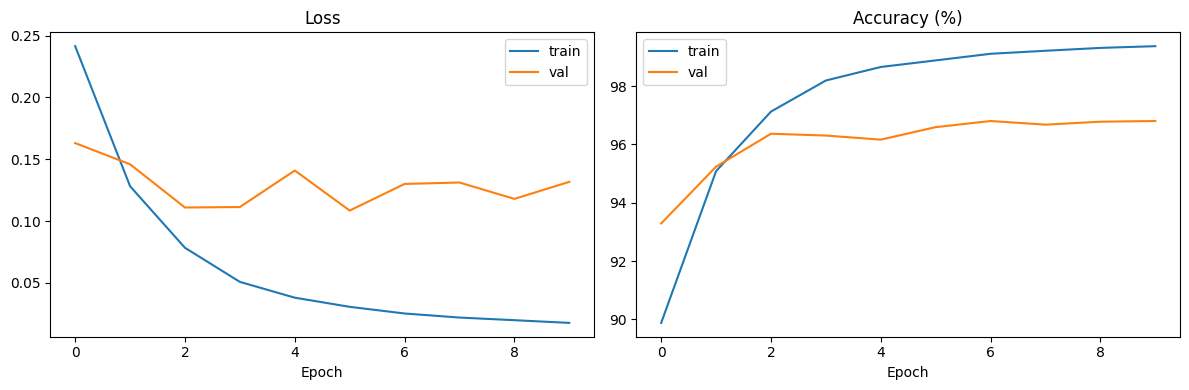

In [11]:
import json

with open(CONFIG["history_path"], "r") as f:
    history = json.load(f)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a*100 for a in history["train_acc"]], label="train")
plt.plot([a*100 for a in history["val_acc"]], label="val")
plt.title("Accuracy (%)")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()